![](https://logoeps.com/wp-content/uploads/2013/04/pontificia-universidad-javeriana-vector-logo.png)
# PONTIFICIA UNIVERSIDAD JAVERIANA

### Procesamiento de Datos

**Fecha:** 14 de agosto de 2026

**Autor del material original:** John Corredor Franco

**Estudiante:** Javier Felipe Aldana Jaramillo

**Tema:** Clases (Programación Orientada a Objetos)

**Objetivos:**
- Repasar qué es una clase, un atributo y un método en Python.
- Practicar la creación de objetos (instancias) y el uso de sus atributos y métodos.
- Resolver la actividad del cuaderno original: construir una clase `Elipse` con métodos para cambiar sus propiedades y dibujarla.
- Documentar la solución de forma breve y personal, y concluir sobre lo aprendido.

## Descripción

Este cuaderno trabaja clases y objetos en Python: cómo se define una clase con `class` y su constructor `__init__`, cómo cada objeto creado a partir de la clase guarda su propio estado en sus atributos (`self.algo`), y cómo se definen métodos (funciones dentro de la clase) que operan sobre ese estado.

**Nota personal:** en el material original la clase se define como `class Rectangulo(object):`, pero más adelante el cuaderno intenta crear un objeto con `Rectangle(20, 5, 'yellow')` (en inglés, sin la clase correspondiente definida), lo que genera un `NameError`. En mis ejemplos usé el mismo nombre de forma consistente para no repetir ese error.

## Comandos nuevos

- `class Nombre(object):` + `def __init__(self, ...):` — define una clase y su constructor, que inicializa los atributos del objeto al crearlo.

In [1]:
class Circulo(object):
    def __init__(self, radio=3, color="azul"):
        self.radio = radio
        self.color = color

Circulo

__main__.Circulo

- `objeto = Clase(args)` — crea una instancia (objeto) concreta a partir de la clase.

In [2]:
mi_circulo = Circulo(5, "rojo")
mi_circulo

- `objeto.atributo` — accede (o cambia) el valor de un atributo del objeto desde fuera de la clase.

In [3]:
mi_circulo.radio, mi_circulo.color

(5, 'rojo')

- `def metodo(self, ...):` y `objeto.metodo(args)` — define un método dentro de la clase y lo ejecuta sobre un objeto puntual.

In [4]:
class Circulo(object):
    def __init__(self, radio=3, color="azul"):
        self.radio = radio
        self.color = color

    def sumar_radio(self, r):
        self.radio = self.radio + r
        return self.radio

mi_circulo = Circulo(5, "rojo")
mi_circulo.sumar_radio(2)

7

- Cada objeto tiene su propio estado — dos instancias de la misma clase no comparten los valores de sus atributos.

In [5]:
c1 = Circulo(1, "rojo")
c2 = Circulo(2, "azul")
c1.radio, c2.radio

(1, 2)

- `dir(objeto)` — lista los atributos y métodos disponibles en un objeto (muchos son heredados de Python).

In [6]:
[m for m in dir(mi_circulo) if not m.startswith("__")]

['color', 'radio', 'sumar_radio']

## Solución del taller

El cuaderno original no trae un examen de preguntas sueltas para este tema; en su lugar plantea una actividad: construir una clase `Elipse` (usando `matplotlib.patches.Ellipse`) con un constructor con valores iniciales y métodos para cambiar el ancho, el alto, el color de relleno, el color de borde, y para dibujarla.

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

In [8]:
class Elipse(object):

    # Constructor
    def __init__(self, xy=(0, 0), width=4, height=2, facecolor="green", edgecolor="black"):
        self.xy = xy
        self.width = width
        self.height = height
        self.facecolor = facecolor
        self.edgecolor = edgecolor

    # Cambiar el ancho
    def cambiar_ancho(self, nuevo_ancho):
        self.width = nuevo_ancho

    # Cambiar el alto
    def cambiar_alto(self, nuevo_alto):
        self.height = nuevo_alto

    # Cambiar el color de relleno
    def cambiar_color_relleno(self, nuevo_color):
        self.facecolor = nuevo_color

    # Cambiar el color de borde
    def cambiar_color_borde(self, nuevo_color):
        self.edgecolor = nuevo_color

    # Dibujar
    def dibujar(self):
        plt.gca().add_patch(Ellipse(self.xy, self.width, self.height,
                                     facecolor=self.facecolor, edgecolor=self.edgecolor))
        plt.axis("scaled")
        plt.show()

Se crea una elipse de prueba y se usan los métodos para modificar sus propiedades antes de dibujarla:

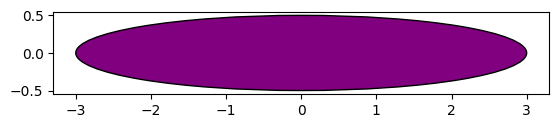

In [9]:
mi_elipse = Elipse(width=3, height=1, facecolor="orange", edgecolor="black")
mi_elipse.cambiar_ancho(6)
mi_elipse.cambiar_color_relleno("purple")
mi_elipse.dibujar()

**Explicación:** Seguí la misma estructura que la clase `Circulo` de los comandos nuevos: un constructor que guarda los valores iniciales en `self`, y un método por cada cambio que pide el enunciado (`cambiar_ancho`, `cambiar_alto`, `cambiar_color_relleno`, `cambiar_color_borde`). El método `dibujar` es el único que no modifica el objeto, solo usa sus atributos actuales para construir el parche `Ellipse` de matplotlib y mostrarlo.

## Conclusiones

Este cuaderno me ayudó a fijar la idea de que una clase es un molde y cada objeto que se crea a partir de ella tiene su propia copia de los atributos, algo que se ve claro al comparar `c1.radio` y `c2.radio` en dos círculos distintos. El bug del `Rectangle`/`Rectangulo` en el material original también fue útil como lección: un nombre mal escrito entre la definición de la clase y su uso es un error fácil de cometer y difícil de detectar a simple vista porque Python no avisa hasta que se intenta crear el objeto. Construir la clase `Elipse` desde cero, en vez de solo ejecutar el ejemplo de `Circulo` ya armado, fue lo que más me sirvió para entender el patrón completo: un método por cada cosa que el objeto debe poder hacer.